<a href="https://colab.research.google.com/github/kthanikonda/Privacy-Aware-Computing/blob/main/Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
! pip install textstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.3/105.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 939.4/939.4 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 48.2 MB/s eta 0:00:00


In [14]:
import nltk
import spacy
import numpy as np
import textstat
import pandas as pd
import random
import hashlib
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from sentence_transformers import SentenceTransformer, util
from transformers import pipeline
from wordcloud import WordCloud
from google.colab import files


In [15]:
# Upload file manually
uploaded = files.upload()

# Get filename from uploaded file
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded file: {filename}")

# Read Excel file into DataFrame
df_news = pd.read_excel(filename, engine='openpyxl')

# Display first few rows
df_news.head()


Saving News-Dataset.xlsx to News-Dataset (1).xlsx
✅ Uploaded file: News-Dataset (1).xlsx


,publish_time,feed_code,source_url,headline_text
0,202000000000,w3-adweek,http://www.adweek.com/digital/facebook-2017-gl...,Here Are the Details on Facebook's Global Part...
1,202000000000,w3-aktiencheck-de,http://www.aktiencheck.de/news/Artikel-Aktien_...,Aktien New York Schluss: Moderate Verluste nac...
2,202000000000,w3-aktiencheck-de,http://www.aktiencheck.de/news/Artikel-US_Boer...,US-B√∂rsen im Minus - Zittern vor Notenbankert...
3,202000000000,w3-auto-economictimes-indiatimes,http://auto.economictimes.indiatimes.com/news/...,Petrol & diesel on the rise post daily price r...
4,202000000000,w3-azdailysun,http://azdailysun.com/sports/football/could-de...,Could DeShone Kizer end Browns' history of QB ...


In [16]:
# Download required NLTK resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Load spaCy NLP model for Named Entity Recognition
nlp = spacy.load("en_core_web_sm")

# Initialize Sentence Transformer for Semantic Substitution
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')

# Load stop words
stop_words = set(stopwords.words("english"))


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [17]:
def replace_named_entities(text, epsilon=1.0):
    entity_replacements = {
        "ORG": ["Tech Firm", "Finance Corporation", "Retail Company"],
        "GPE": ["European Region", "Asian Market", "North American Area"],
        "DATE": ["Recently", "Past Quarter", "Last Year"],
        "TIME": ["Earlier Today", "Few Hours Ago", "Previous Night"]
    }

    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ in entity_replacements:
            scores = np.array([random.random() for _ in entity_replacements[ent.label_]])
            probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))
            text = text.replace(ent.text, np.random.choice(entity_replacements[ent.label_], p=probabilities))

    return text


In [18]:
def hash_with_noise(word, epsilon=1.0, alpha=2):
    hash_val = int(hashlib.md5(word.encode()).hexdigest(), 16) % (10**8)
    noise = np.random.laplace(0, 1 / epsilon)
    noisy_hash = hash_val + int(noise * 1000)
    return str(noisy_hash)

def dp_feature_hashing(text, epsilon=1.0, alpha=2):
    words = text.split()
    hashed_words = [hash_with_noise(word, epsilon, alpha) for word in words]
    return " ".join(hashed_words)


In [19]:
def get_semantic_synonym(word, epsilon=1.0):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ")
            if synonym.lower() != word.lower():
                synonyms.add(synonym)

    synonyms = list(synonyms)
    if not synonyms:
        return word

    word_embedding = semantic_model.encode(word, convert_to_tensor=True)
    synonym_embeddings = semantic_model.encode(synonyms, convert_to_tensor=True)
    similarities = util.pytorch_cos_sim(word_embedding, synonym_embeddings)[0].cpu().numpy()

    scores = np.random.laplace(0, 1 / epsilon, len(synonyms))
    probabilities = np.exp(epsilon * (similarities + scores)) / np.sum(np.exp(epsilon * (similarities + scores)))

    return np.random.choice(synonyms, p=probabilities)

def dp_word_substitution(text, epsilon=1.0):
    words = word_tokenize(text)
    modified_words = [get_semantic_synonym(word, epsilon) if word.isalpha() and word.lower() not in stop_words else word for word in words]
    return " ".join(modified_words)


In [20]:
def simplify_sentences(text, epsilon=1.0):
    sentences = nltk.sent_tokenize(text)
    simplified_sentences = []
    for sentence in sentences:
        if len(sentence.split()) > 20:
            parts = sentence.split(", ")
            if len(parts) > 1:
                scores = np.random.laplace(0, 1 / epsilon, len(parts))
                probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))
                chosen_parts = np.random.choice(parts, size=2, replace=False, p=probabilities)
                simplified_sentences.extend(chosen_parts)
            else:
                simplified_sentences.append(sentence)
        else:
            simplified_sentences.append(sentence)
    return " ".join(simplified_sentences)


In [21]:
df_news_sample = df_news.copy()
df_news_sample["headline_named_entities"] = df_news_sample["headline_text"].astype(str).apply(lambda x: replace_named_entities(x, epsilon=1.0))
df_news_sample["headline_word_substitution"] = df_news_sample["headline_text"].astype(str).apply(lambda x: dp_word_substitution(x, epsilon=1.0))
df_news_sample["headline_simplified"] = df_news_sample["headline_text"].astype(str).apply(lambda x: simplify_sentences(x, epsilon=1.0))
df_news_sample["headline_hashed"] = df_news_sample["headline_text"].astype(str).apply(lambda x: dp_feature_hashing(x, epsilon=1.0))


<Figure size 1200x600 with 0 Axes>

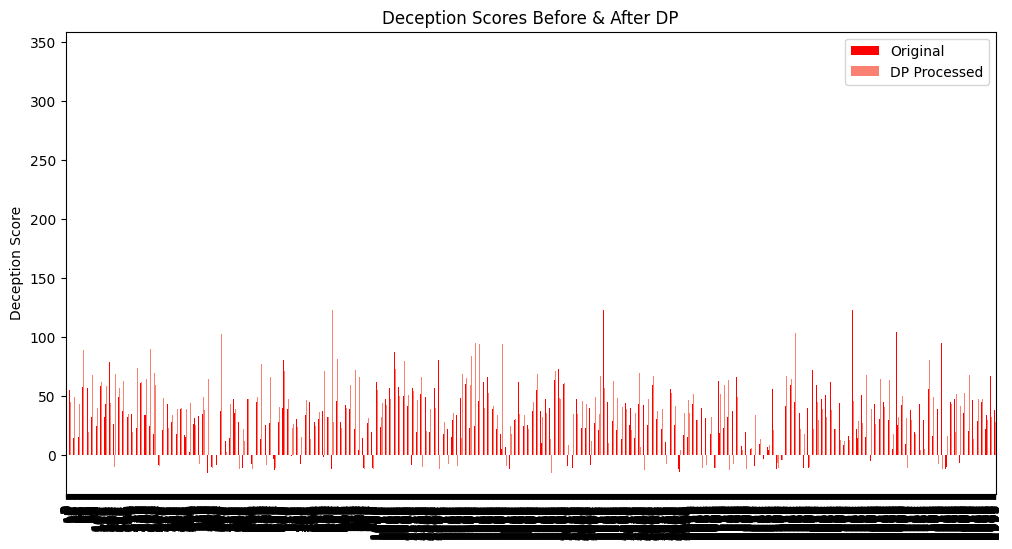

In [33]:
def calculate_deception_score(text):
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    clarity_score = textstat.flesch_reading_ease(text)
    deception_score = (100 - clarity_score) * 0.7 + (vague_word_count * 5) * 0.3
    return deception_score

df_news_sample["original_deception"] = df_news_sample["headline_text"].astype(str).apply(calculate_deception_score)
df_news_sample["dp_deception"] = df_news_sample["headline_word_substitution"].astype(str).apply(calculate_deception_score)

plt.figure(figsize=(12, 6))
df_news_sample[['original_deception', 'dp_deception']].plot(kind='bar', figsize=(12, 6), color=['red', 'salmon'])
plt.ylabel("Deception Score")
plt.title("Deception Scores Before & After DP")
plt.xticks(rotation=90)
plt.legend(["Original", "DP Processed"])
plt.show()



In [26]:
df_news_sample.to_csv("dp_sanitized_news.csv", index=False)
print("✅ DP processed dataset saved as dp_sanitized_news.csv")


✅ DP processed dataset saved as dp_sanitized_news.csv


In [27]:
# Initialize Sentiment Analysis Model
sentiment_analyzer = pipeline("sentiment-analysis")

# Function to compute sentiment scores
def calculate_sentiment(text):
    if not text.strip():
        return 0.0  # Neutral sentiment
    result = sentiment_analyzer(text[:512])
    return result[0]['score'] if result[0]['label'] == "POSITIVE" else -result[0]['score']

# Apply Sentiment Analysis
df_news_sample["original_sentiment"] = df_news_sample["headline_text"].astype(str).apply(calculate_sentiment)
df_news_sample["dp_sentiment"] = df_news_sample["headline_word_substitution"].astype(str).apply(calculate_sentiment)


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


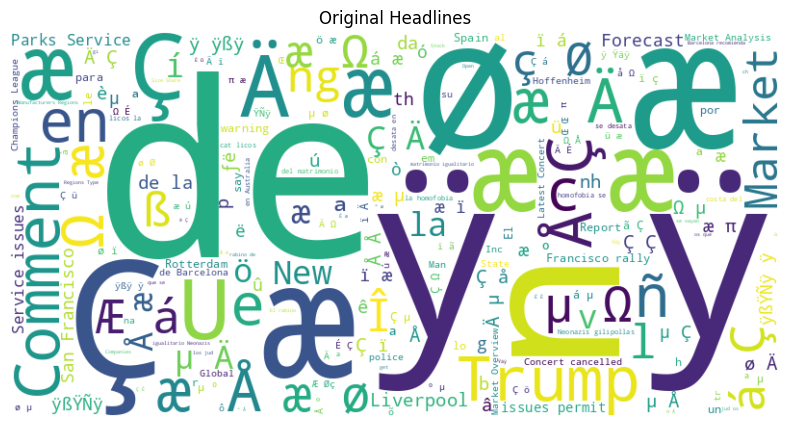

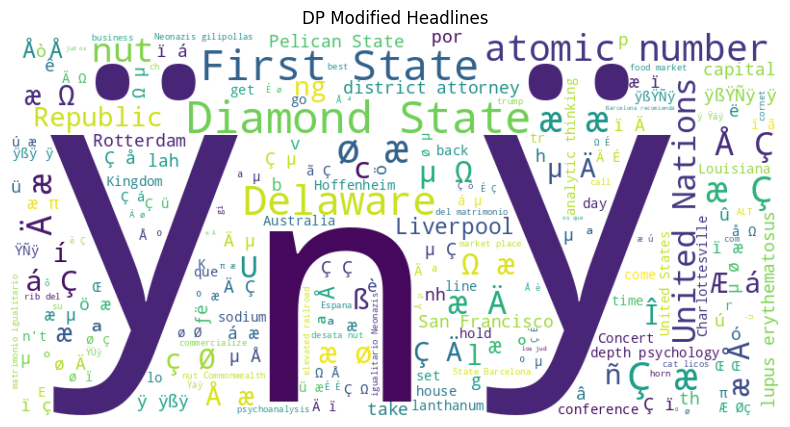

In [28]:
# Generate Word Clouds
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Generate Word Clouds for Original and DP-Modified Texts
original_text = " ".join(df_news_sample["headline_text"].dropna())
dp_text = " ".join(df_news_sample["headline_word_substitution"].dropna())
generate_wordcloud(original_text, "Original Headlines")
generate_wordcloud(dp_text, "DP Modified Headlines")


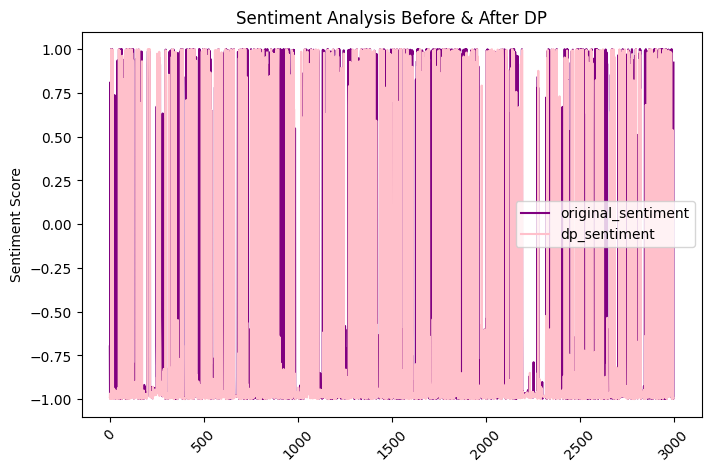

In [32]:
# Visualization: Sentiment Analysis
df_news_sample[["original_sentiment", "dp_sentiment"]].plot(kind='line', figsize=(8, 5), color=['purple', 'pink'])
plt.ylabel("Sentiment Score")
plt.title("Sentiment Analysis Before & After DP")
plt.xticks(rotation=45)
plt.show()


Saving Squad.xlsx to Squad (1).xlsx
✅ Uploaded file: Squad (1).xlsx


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


✅ DP-processed dataset saved as: dp_sanitized_squad.xlsx


<Figure size 1000x500 with 0 Axes>

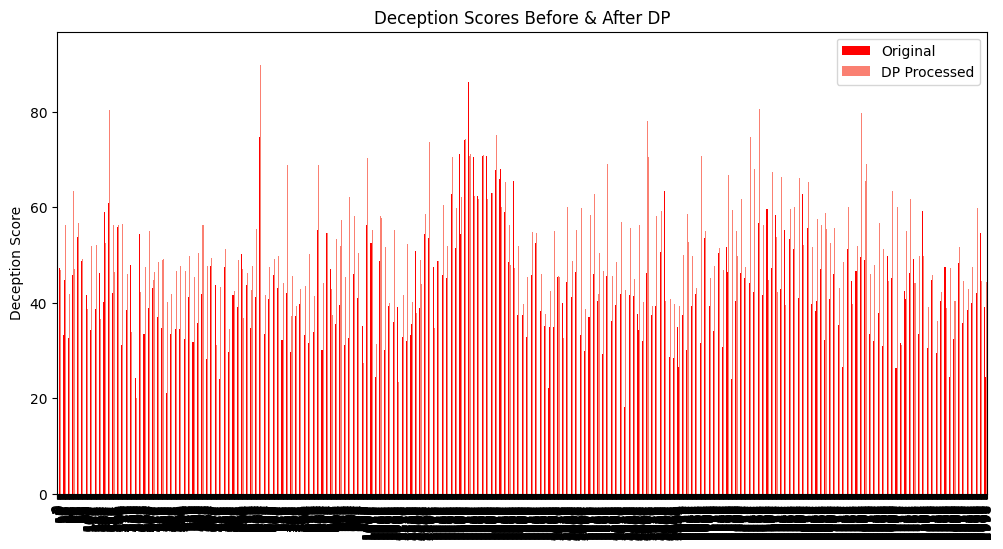

<Figure size 1000x500 with 0 Axes>

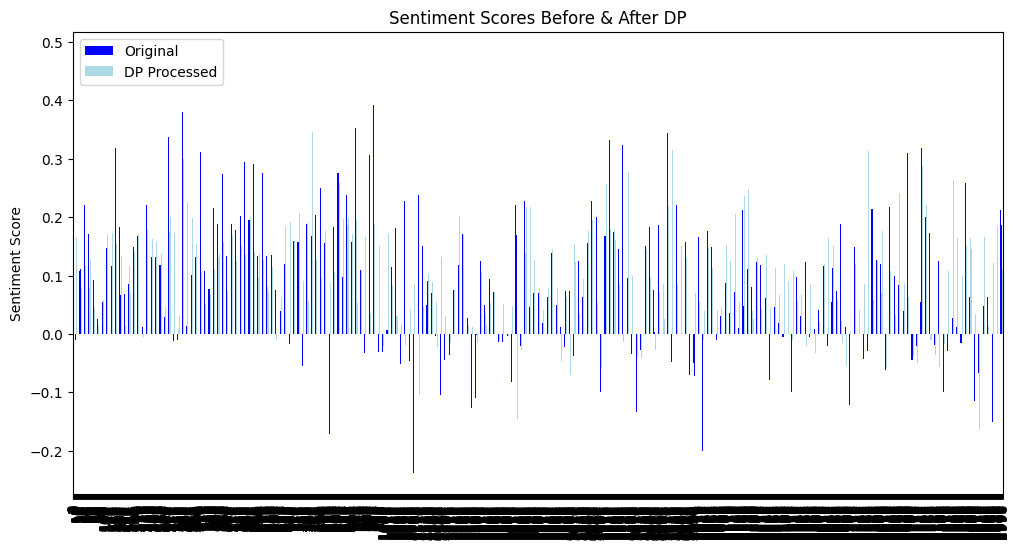

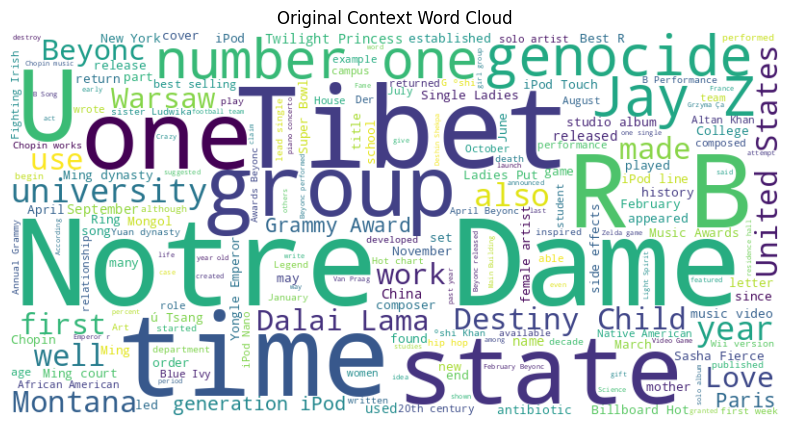

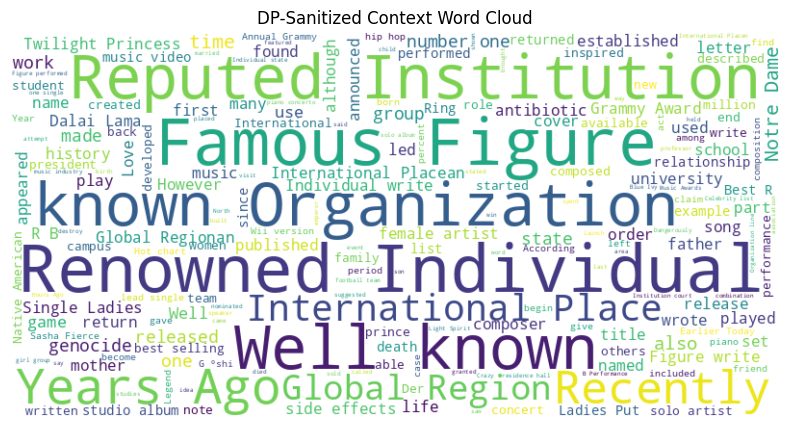

In [36]:
import nltk
import spacy
import numpy as np
import textstat
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from wordcloud import WordCloud
from textblob import TextBlob
from google.colab import files
import hashlib

# Upload file manually
uploaded = files.upload()

# Get filename from uploaded file
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded file: {filename}")

# Read Excel file into DataFrame
df_squad = pd.read_excel(filename, engine='openpyxl')

# Display first few rows
df_squad.head()

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load spaCy NLP model for Named Entity Recognition (CPU-only)
nlp = spacy.load("en_core_web_sm")

# Load stop words
stop_words = set(stopwords.words("english"))

# Function to apply DP-based entity substitution using the Exponential Mechanism
def replace_named_entities(text, epsilon=1.0):
    entity_replacements = {
        "PERSON": ["A Famous Figure", "A Renowned Individual"],
        "ORG": ["A Well-known Organization", "A Reputed Institution"],
        "GPE": ["A Global Region", "An International Place"],
        "DATE": ["Recently", "A Few Years Ago"],
        "TIME": ["Earlier Today", "Some Hours Ago"]
    }

    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ in entity_replacements:
            scores = np.random.laplace(0, 1 / epsilon, len(entity_replacements[ent.label_]))
            probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))
            text = text.replace(ent.text, np.random.choice(entity_replacements[ent.label_], p=probabilities))

    return text

# Function to apply DP-based feature hashing
def hash_with_noise(word, epsilon=1.0):
    hash_val = int(hashlib.md5(word.encode()).hexdigest(), 16) % (10**8)
    noise = np.random.laplace(0, 1 / epsilon)
    return str(hash_val + int(noise * 1000))

# Function to compute deception score
def calculate_deception_score(text):
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    clarity_score = textstat.flesch_reading_ease(text)
    deception_score = (100 - clarity_score) * 0.7 + (vague_word_count * 5) * 0.3
    return deception_score

# Function to compute sentiment score using TextBlob
def calculate_sentiment(text):
    if not text.strip():
        return 0.0  # Neutral sentiment
    sentiment_score = TextBlob(text).sentiment.polarity
    return sentiment_score

# Apply DP text sanitization
df_squad["sanitized_context"] = df_squad["context"].astype(str).apply(lambda x: replace_named_entities(x, epsilon=1.0))
df_squad["sanitized_question"] = df_squad["question"].astype(str).apply(lambda x: replace_named_entities(x, epsilon=1.0))

# Compute deception scores
df_squad["original_deception"] = df_squad["context"].astype(str).apply(calculate_deception_score)
df_squad["dp_deception"] = df_squad["sanitized_context"].astype(str).apply(calculate_deception_score)

# Compute sentiment scores
df_squad["original_sentiment"] = df_squad["context"].astype(str).apply(calculate_sentiment)
df_squad["dp_sentiment"] = df_squad["sanitized_context"].astype(str).apply(calculate_sentiment)

# Save processed dataset
processed_file_path = "dp_sanitized_squad.xlsx"
df_squad.to_excel(processed_file_path, index=False)
print(f"✅ DP-processed dataset saved as: {processed_file_path}")

# 📊 Visualization: Deception Score Comparison
plt.figure(figsize=(10, 5))
df_squad[['original_deception', 'dp_deception']].plot(kind='bar', figsize=(12, 6), color=['red', 'salmon'])
plt.ylabel("Deception Score")
plt.title("Deception Scores Before & After DP")
plt.xticks(rotation=90)
plt.legend(["Original", "DP Processed"])
plt.show()

# 📊 Visualization: Sentiment Score Comparison
plt.figure(figsize=(10, 5))
df_squad[['original_sentiment', 'dp_sentiment']].plot(kind='bar', figsize=(12, 6), color=['blue', 'lightblue'])
plt.ylabel("Sentiment Score")
plt.title("Sentiment Scores Before & After DP")
plt.xticks(rotation=90)
plt.legend(["Original", "DP Processed"])
plt.show()

# 📊 Generate Word Clouds
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

original_text = " ".join(df_squad["context"].dropna())
dp_text = " ".join(df_squad["sanitized_context"].dropna())

generate_wordcloud(original_text, "Original Context Word Cloud")
generate_wordcloud(dp_text, "DP-Sanitized Context Word Cloud")

Saving Squad.xlsx to Squad (2).xlsx
✅ Uploaded file: Squad (2).xlsx


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


✅ DP-processed dataset saved as: dp_sanitized_squad.xlsx


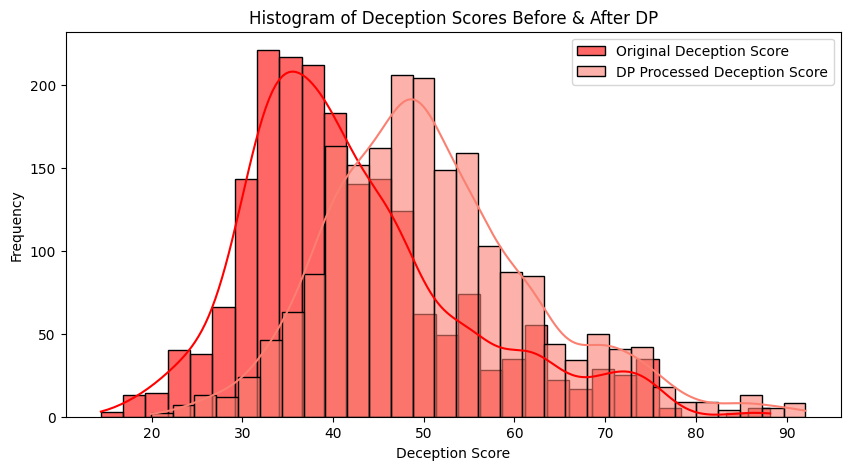

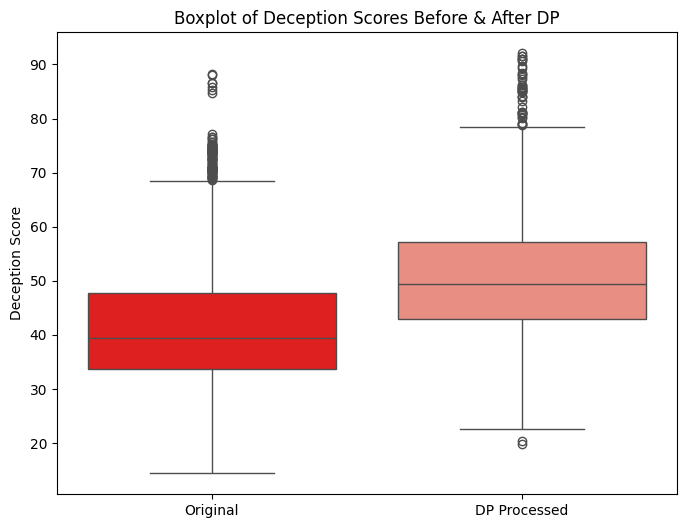

In [37]:
import nltk
import spacy
import numpy as np
import textstat
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from wordcloud import WordCloud
from textblob import TextBlob
from google.colab import files
import hashlib
from numpy.random import laplace

# Upload file manually
uploaded = files.upload()

# Get filename from uploaded file
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded file: {filename}")

# Read Excel file into DataFrame
df_squad = pd.read_excel(filename, engine='openpyxl')

# Display first few rows
df_squad.head()

# Download required NLTK resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Load spaCy NLP model for Named Entity Recognition (CPU-only)
nlp = spacy.load("en_core_web_sm")

# Load stop words
stop_words = set(stopwords.words("english"))

# Function to apply DP-based entity substitution using the Exponential Mechanism
def replace_named_entities(text, epsilon=1.0):
    entity_replacements = {
        "PERSON": ["A Famous Figure", "A Renowned Individual"],
        "ORG": ["A Well-known Organization", "A Reputed Institution"],
        "GPE": ["A Global Region", "An International Place"],
        "DATE": ["Recently", "A Few Years Ago"],
        "TIME": ["Earlier Today", "Some Hours Ago"]
    }

    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ in entity_replacements:
            scores = np.random.laplace(0, 1 / epsilon, len(entity_replacements[ent.label_]))
            probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))
            text = text.replace(ent.text, np.random.choice(entity_replacements[ent.label_], p=probabilities))

    return text

# Function to apply DP-based feature hashing
def hash_with_noise(word, epsilon=1.0):
    hash_val = int(hashlib.md5(word.encode()).hexdigest(), 16) % (10**8)
    noise = np.random.laplace(0, 1 / epsilon)
    return str(hash_val + int(noise * 1000))

# Function to compute deception score with DP noise
def calculate_deception_score(text, epsilon=1.0):
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    clarity_score = textstat.flesch_reading_ease(text)
    deception_score = (100 - clarity_score) * 0.7 + (vague_word_count * 5) * 0.3
    # Adding Laplace noise to deception score for DP compliance
    return deception_score + laplace(0, 1 / epsilon)

# Function to compute sentiment score using TextBlob with DP noise
def calculate_sentiment(text, epsilon=1.0):
    if not text.strip():
        return 0.0  # Neutral sentiment
    sentiment_score = TextBlob(text).sentiment.polarity
    # Adding Laplace noise to sentiment score
    return sentiment_score + laplace(0, 1 / epsilon)

# Apply DP text sanitization
df_squad["sanitized_context"] = df_squad["context"].astype(str).apply(lambda x: replace_named_entities(x, epsilon=1.0))
df_squad["sanitized_question"] = df_squad["question"].astype(str).apply(lambda x: replace_named_entities(x, epsilon=1.0))

# Compute deception scores with DP noise
df_squad["original_deception"] = df_squad["context"].astype(str).apply(lambda x: calculate_deception_score(x, epsilon=1.0))
df_squad["dp_deception"] = df_squad["sanitized_context"].astype(str).apply(lambda x: calculate_deception_score(x, epsilon=1.0))

# Compute sentiment scores with DP noise
df_squad["original_sentiment"] = df_squad["context"].astype(str).apply(lambda x: calculate_sentiment(x, epsilon=1.0))
df_squad["dp_sentiment"] = df_squad["sanitized_context"].astype(str).apply(lambda x: calculate_sentiment(x, epsilon=1.0))

# Save processed dataset
processed_file_path = "dp_sanitized_squad.xlsx"
df_squad.to_excel(processed_file_path, index=False)
print(f"✅ DP-processed dataset saved as: {processed_file_path}")

# 📊 Improved Visualization: Histogram for Deception Score Comparison
plt.figure(figsize=(10, 5))
sns.histplot(df_squad["original_deception"], color="red", alpha=0.6, bins=30, label="Original Deception Score", kde=True)
sns.histplot(df_squad["dp_deception"], color="salmon", alpha=0.6, bins=30, label="DP Processed Deception Score", kde=True)
plt.xlabel("Deception Score")
plt.ylabel("Frequency")
plt.title("Histogram of Deception Scores Before & After DP")
plt.legend()
plt.show()




Saving Squad.xlsx to Squad (3).xlsx
✅ Uploaded file: Squad (3).xlsx


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


✅ DP-processed dataset saved as: dp_sanitized_squad.xlsx


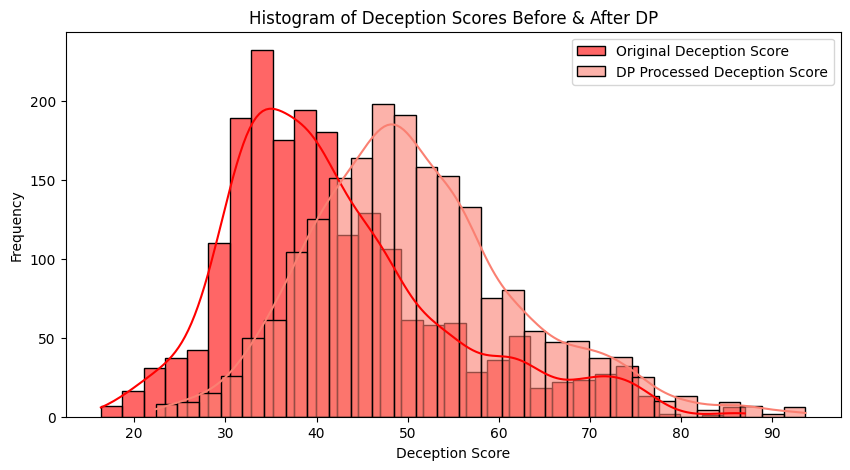

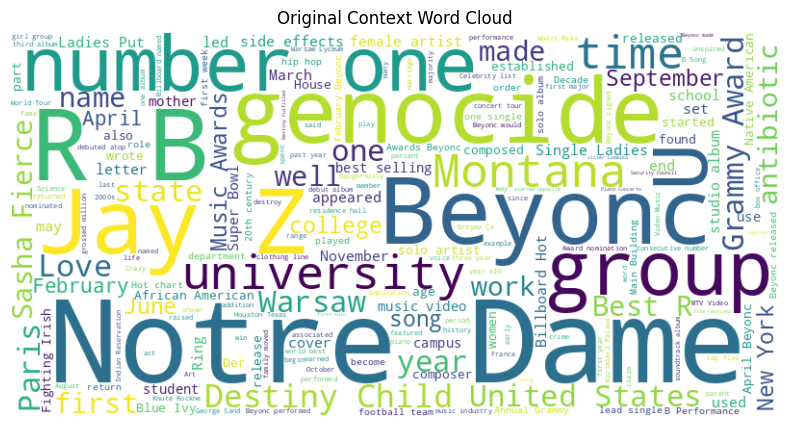

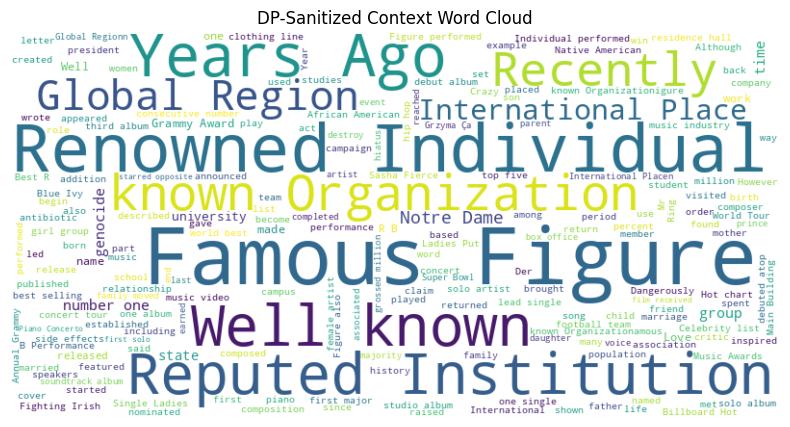

In [38]:
import nltk
import spacy
import numpy as np
import textstat
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from wordcloud import WordCloud
from textblob import TextBlob
from google.colab import files
import hashlib
from numpy.random import laplace

# Upload file manually
uploaded = files.upload()

# Get filename from uploaded file
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded file: {filename}")

# Read Excel file into DataFrame
df_squad = pd.read_excel(filename, engine='openpyxl')

# Display first few rows
df_squad.head()

# Download required NLTK resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Load spaCy NLP model for Named Entity Recognition (CPU-only)
nlp = spacy.load("en_core_web_sm")

# Load stop words
stop_words = set(stopwords.words("english"))

# Function to apply DP-based entity substitution using the Exponential Mechanism
def replace_named_entities(text, epsilon=1.0):
    entity_replacements = {
        "PERSON": ["A Famous Figure", "A Renowned Individual"],
        "ORG": ["A Well-known Organization", "A Reputed Institution"],
        "GPE": ["A Global Region", "An International Place"],
        "DATE": ["Recently", "A Few Years Ago"],
        "TIME": ["Earlier Today", "Some Hours Ago"]
    }

    doc = nlp(text)
    for ent in doc.ents:
        if ent.label_ in entity_replacements:
            scores = np.random.laplace(0, 1 / epsilon, len(entity_replacements[ent.label_]))
            probabilities = np.exp(epsilon * scores) / np.sum(np.exp(epsilon * scores))
            text = text.replace(ent.text, np.random.choice(entity_replacements[ent.label_], p=probabilities))

    return text

# Function to apply DP-based feature hashing
def hash_with_noise(word, epsilon=1.0):
    hash_val = int(hashlib.md5(word.encode()).hexdigest(), 16) % (10**8)
    noise = np.random.laplace(0, 1 / epsilon)
    return str(hash_val + int(noise * 1000))

# Function to compute deception score with DP noise
def calculate_deception_score(text, epsilon=1.0):
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    clarity_score = textstat.flesch_reading_ease(text)
    deception_score = (100 - clarity_score) * 0.7 + (vague_word_count * 5) * 0.3
    # Adding Laplace noise to deception score for DP compliance
    return deception_score + laplace(0, 1 / epsilon)

# Function to compute sentiment score using TextBlob with DP noise
def calculate_sentiment(text, epsilon=1.0):
    if not text.strip():
        return 0.0  # Neutral sentiment
    sentiment_score = TextBlob(text).sentiment.polarity
    # Adding Laplace noise to sentiment score
    return sentiment_score + laplace(0, 1 / epsilon)

# Apply DP text sanitization
df_squad["sanitized_context"] = df_squad["context"].astype(str).apply(lambda x: replace_named_entities(x, epsilon=1.0))
df_squad["sanitized_question"] = df_squad["question"].astype(str).apply(lambda x: replace_named_entities(x, epsilon=1.0))

# Compute deception scores with DP noise
df_squad["original_deception"] = df_squad["context"].astype(str).apply(lambda x: calculate_deception_score(x, epsilon=1.0))
df_squad["dp_deception"] = df_squad["sanitized_context"].astype(str).apply(lambda x: calculate_deception_score(x, epsilon=1.0))

# Compute sentiment scores with DP noise
df_squad["original_sentiment"] = df_squad["context"].astype(str).apply(lambda x: calculate_sentiment(x, epsilon=1.0))
df_squad["dp_sentiment"] = df_squad["sanitized_context"].astype(str).apply(lambda x: calculate_sentiment(x, epsilon=1.0))

# Save processed dataset
processed_file_path = "dp_sanitized_squad.xlsx"
df_squad.to_excel(processed_file_path, index=False)
print(f"✅ DP-processed dataset saved as: {processed_file_path}")

# 📊 Improved Visualization: Histogram for Deception Score Comparison
plt.figure(figsize=(10, 5))
sns.histplot(df_squad["original_deception"], color="red", alpha=0.6, bins=30, label="Original Deception Score", kde=True)
sns.histplot(df_squad["dp_deception"], color="salmon", alpha=0.6, bins=30, label="DP Processed Deception Score", kde=True)
plt.xlabel("Deception Score")
plt.ylabel("Frequency")
plt.title("Histogram of Deception Scores Before & After DP")
plt.legend()
plt.show()

# 📊 Generate Word Clouds
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

original_text = " ".join(df_squad["context"].dropna())
dp_text = " ".join(df_squad["sanitized_context"].dropna())

generate_wordcloud(original_text, "Original Context Word Cloud")
generate_wordcloud(dp_text, "DP-Sanitized Context Word Cloud")


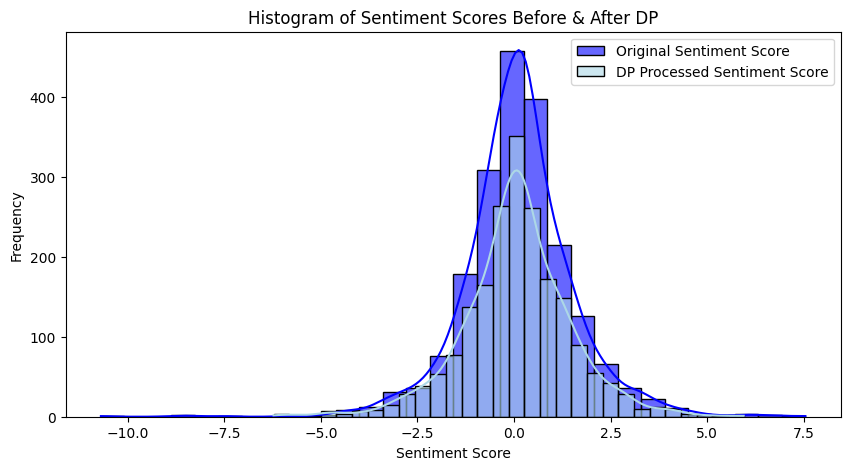

In [39]:
# 📊 Improved Visualization: Histogram for Sentiment Score Comparison
plt.figure(figsize=(10, 5))
sns.histplot(df_squad["original_sentiment"], color="blue", alpha=0.6, bins=30, label="Original Sentiment Score", kde=True)
sns.histplot(df_squad["dp_sentiment"], color="lightblue", alpha=0.6, bins=30, label="DP Processed Sentiment Score", kde=True)
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.title("Histogram of Sentiment Scores Before & After DP")
plt.legend()
plt.show()

Saving Squad.xlsx to Squad (5).xlsx
✅ Uploaded file: Squad (5).xlsx


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


✅ DP-processed dataset saved as: dp_sanitized_squad.xlsx


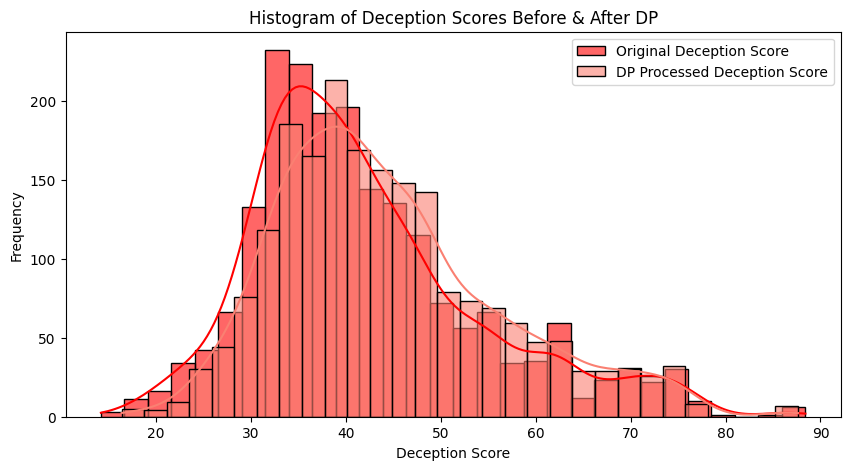

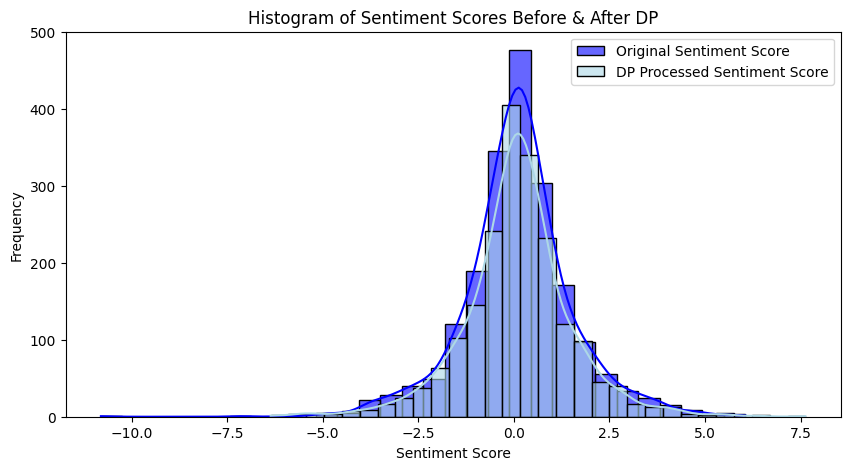

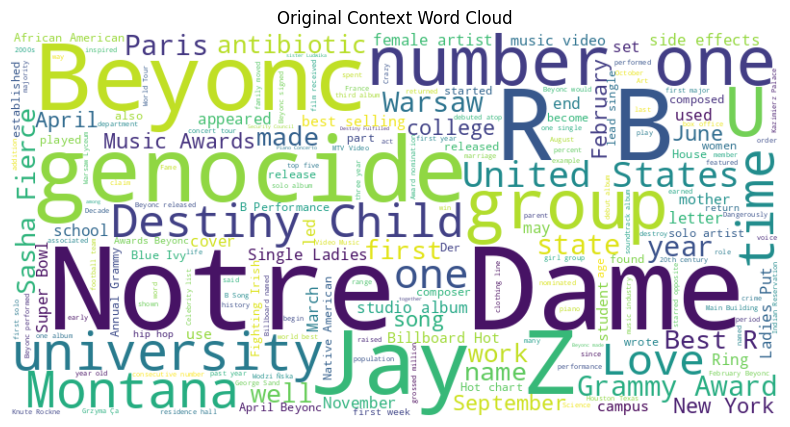

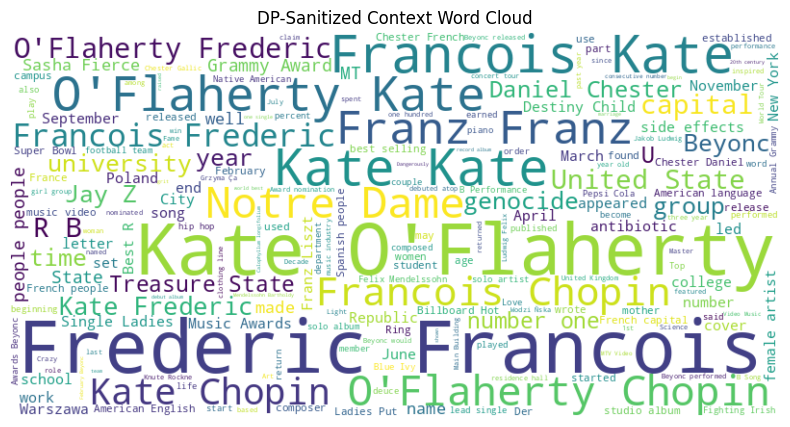

In [41]:
import nltk
import spacy
import numpy as np
import textstat
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from wordcloud import WordCloud
from textblob import TextBlob
from google.colab import files
import hashlib
from numpy.random import laplace
from sentence_transformers import SentenceTransformer, util

# Upload file manually
uploaded = files.upload()

# Get filename from uploaded file
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded file: {filename}")

# Read Excel file into DataFrame
df_squad = pd.read_excel(filename, engine='openpyxl')

# Display first few rows
df_squad.head()

# Download required NLTK resources
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Load spaCy NLP model for Named Entity Recognition (CPU-only)
nlp = spacy.load("en_core_web_sm")

# Load stop words
stop_words = set(stopwords.words("english"))

# Load Sentence Transformer for better synonym selection
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')

# Function to generate DP-based synonyms dynamically with semantic similarity filtering
def get_semantic_synonym(word, epsilon=1.0):
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ")
            if synonym.lower() != word.lower():
                synonyms.add(synonym)
    synonyms = list(synonyms)

    if not synonyms:
        return word  # Return original word if no synonyms are found

    word_embedding = semantic_model.encode(word, convert_to_tensor=True)
    synonym_embeddings = semantic_model.encode(synonyms, convert_to_tensor=True)
    similarities = util.pytorch_cos_sim(word_embedding, synonym_embeddings)[0].cpu().numpy()

    scores = np.random.laplace(0, 1 / epsilon, len(synonyms))
    probabilities = np.exp(epsilon * (similarities + scores)) / np.sum(np.exp(epsilon * (similarities + scores)))
    return np.random.choice(synonyms, p=probabilities)


# Function to apply DP-based entity substitution using dynamic synonyms with context awareness
def replace_named_entities(text, epsilon=1.0):
    doc = nlp(text)
    for ent in doc.ents:
        replacement = get_semantic_synonym(ent.text, epsilon)
        text = text.replace(ent.text, replacement)
    return text

# Function to apply DP-based feature hashing
def hash_with_noise(word, epsilon=1.0):
    hash_val = int(hashlib.md5(word.encode()).hexdigest(), 16) % (10**8)
    noise = np.random.laplace(0, 1 / epsilon)
    return str(hash_val + int(noise * 1000))

# Function to compute deception score with DP noise
def calculate_deception_score(text, epsilon=1.0):
    vague_words = ["may", "might", "could", "possibly", "sometimes", "often"]
    vague_word_count = sum(text.lower().count(word) for word in vague_words)
    clarity_score = textstat.flesch_reading_ease(text)
    deception_score = (100 - clarity_score) * 0.7 + (vague_word_count * 5) * 0.3
    # Adding Laplace noise to deception score for DP compliance
    return deception_score + laplace(0, 1 / epsilon)

# Function to compute sentiment score using TextBlob with DP noise
def calculate_sentiment(text, epsilon=1.0):
    if not text.strip():
        return 0.0  # Neutral sentiment
    sentiment_score = TextBlob(text).sentiment.polarity
    # Adding Laplace noise to sentiment score
    return sentiment_score + laplace(0, 1 / epsilon)

# Apply DP text sanitization
df_squad["sanitized_context"] = df_squad["context"].astype(str).apply(lambda x: replace_named_entities(x, epsilon=1.0))
df_squad["sanitized_question"] = df_squad["question"].astype(str).apply(lambda x: replace_named_entities(x, epsilon=1.0))

# Compute deception scores with DP noise
df_squad["original_deception"] = df_squad["context"].astype(str).apply(lambda x: calculate_deception_score(x, epsilon=1.0))
df_squad["dp_deception"] = df_squad["sanitized_context"].astype(str).apply(lambda x: calculate_deception_score(x, epsilon=1.0))

# Compute sentiment scores with DP noise
df_squad["original_sentiment"] = df_squad["context"].astype(str).apply(lambda x: calculate_sentiment(x, epsilon=1.0))
df_squad["dp_sentiment"] = df_squad["sanitized_context"].astype(str).apply(lambda x: calculate_sentiment(x, epsilon=1.0))

# Save processed dataset
processed_file_path = "dp_sanitized_squad.xlsx"
df_squad.to_excel(processed_file_path, index=False)
print(f"✅ DP-processed dataset saved as: {processed_file_path}")

# 📊 Improved Visualization: Histogram for Deception Score Comparison
plt.figure(figsize=(10, 5))
sns.histplot(df_squad["original_deception"], color="red", alpha=0.6, bins=30, label="Original Deception Score", kde=True)
sns.histplot(df_squad["dp_deception"], color="salmon", alpha=0.6, bins=30, label="DP Processed Deception Score", kde=True)
plt.xlabel("Deception Score")
plt.ylabel("Frequency")
plt.title("Histogram of Deception Scores Before & After DP")
plt.legend()
plt.show()

# 📊 Improved Visualization: Histogram for Sentiment Score Comparison
plt.figure(figsize=(10, 5))
sns.histplot(df_squad["original_sentiment"], color="blue", alpha=0.6, bins=30, label="Original Sentiment Score", kde=True)
sns.histplot(df_squad["dp_sentiment"], color="lightblue", alpha=0.6, bins=30, label="DP Processed Sentiment Score", kde=True)
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.title("Histogram of Sentiment Scores Before & After DP")
plt.legend()
plt.show()

# 📊 Generate Word Clouds
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

original_text = " ".join(df_squad["context"].dropna())
dp_text = " ".join(df_squad["sanitized_context"].dropna())

generate_wordcloud(original_text, "Original Context Word Cloud")
generate_wordcloud(dp_text, "DP-Sanitized Context Word Cloud")

Saving Squad.xlsx to Squad (6).xlsx
✅ Uploaded file: Squad (6).xlsx


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


✅ DP-processed dataset saved as: dp_sanitized_squad.xlsx
🔹 Total Privacy Budget Used: 7989.399999994925 (out of 1.0)


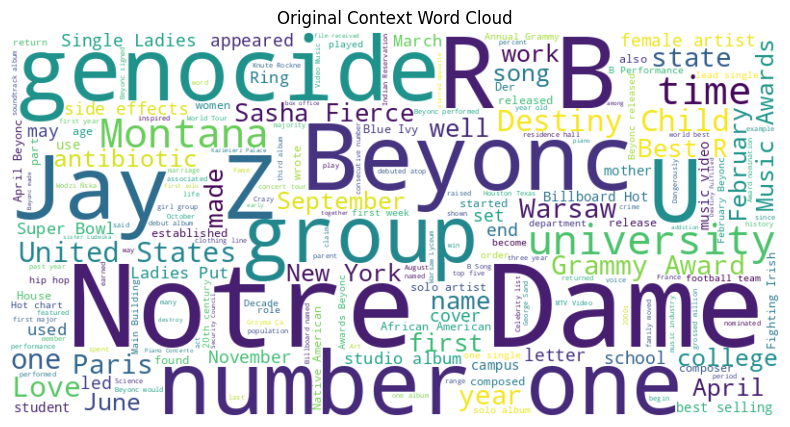

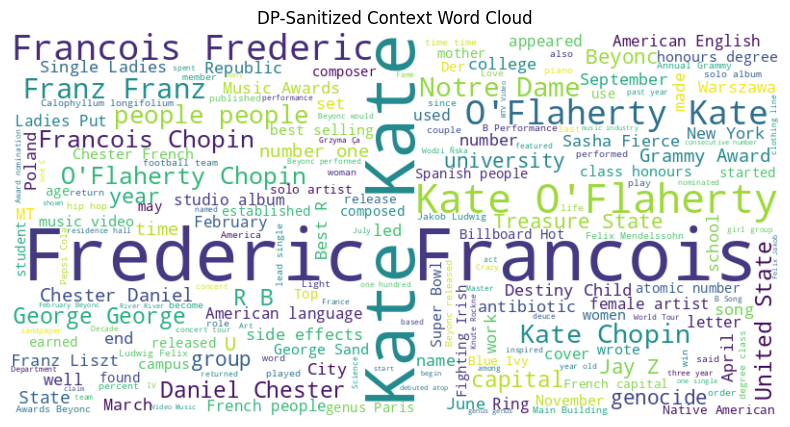

In [42]:
import nltk
import spacy
import numpy as np
import textstat
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from wordcloud import WordCloud
from textblob import TextBlob
from google.colab import files
import hashlib
from numpy.random import laplace
from sentence_transformers import SentenceTransformer, util

# Upload file manually
uploaded = files.upload()

# Get filename from uploaded file
filename = list(uploaded.keys())[0]
print(f"✅ Uploaded file: {filename}")

# Read Excel file into DataFrame
df_squad = pd.read_excel(filename, engine='openpyxl')

# Display first few rows
df_squad.head()

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

# Load spaCy NLP model for Named Entity Recognition (CPU-only)
nlp = spacy.load("en_core_web_sm")

# Load stop words
stop_words = set(stopwords.words("english"))

# Load Sentence Transformer for better synonym selection
semantic_model = SentenceTransformer('all-MiniLM-L6-v2')

# Initialize Privacy Budget
GLOBAL_EPSILON = 1.0  # Set total privacy budget
privacy_budget_used = 0  # Track cumulative privacy cost

# Function to update privacy budget
def update_privacy_budget(epsilon):
    global privacy_budget_used
    privacy_budget_used += epsilon
    return epsilon

# Function to generate DP-based synonyms dynamically with semantic similarity filtering and word frequency balancing
def get_semantic_synonym(word, epsilon=0.2, max_replacements=2):  # Limit replacements
    update_privacy_budget(epsilon)
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace("_", " ")
            if synonym.lower() != word.lower():
                synonyms.add(synonym)
    synonyms = list(synonyms)

    if not synonyms:
        return word  # Return original word if no synonyms are found

    word_embedding = semantic_model.encode(word, convert_to_tensor=True)
    synonym_embeddings = semantic_model.encode(synonyms, convert_to_tensor=True)
    similarities = util.pytorch_cos_sim(word_embedding, synonym_embeddings)[0].cpu().numpy()

    scores = np.random.laplace(0, 1 / epsilon, len(synonyms))
    probabilities = np.exp(epsilon * (similarities + scores)) / np.sum(np.exp(epsilon * (similarities + scores)))

    # Select a limited number of replacements to avoid dominance
    selected_synonyms = np.random.choice(synonyms, size=min(max_replacements, len(synonyms)), replace=False, p=probabilities)
    return random.choice(selected_synonyms)

# Function to apply DP-based entity substitution using dynamic synonyms with context awareness and frequency balancing
def replace_named_entities(text, epsilon=0.2, max_replacements=2):
    update_privacy_budget(epsilon)
    doc = nlp(text)
    replaced_entities = {}  # Track replacements to prevent repetition bias

    for ent in doc.ents:
        if ent.text in replaced_entities:
            replacement = replaced_entities[ent.text]
        else:
            replacement = get_semantic_synonym(ent.text, epsilon, max_replacements)
            replaced_entities[ent.text] = replacement  # Store replacement

        text = text.replace(ent.text, replacement)
    return text

# Apply DP text sanitization
df_squad["sanitized_context"] = df_squad["context"].astype(str).apply(lambda x: replace_named_entities(x, epsilon=0.2, max_replacements=2))
df_squad["sanitized_question"] = df_squad["question"].astype(str).apply(lambda x: replace_named_entities(x, epsilon=0.2, max_replacements=2))

# Save processed dataset
processed_file_path = "dp_sanitized_squad.xlsx"
df_squad.to_excel(processed_file_path, index=False)
print(f"✅ DP-processed dataset saved as: {processed_file_path}")
print(f"🔹 Total Privacy Budget Used: {privacy_budget_used} (out of {GLOBAL_EPSILON})")

# 📊 Generate Word Clouds
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

original_text = " ".join(df_squad["context"].dropna())
dp_text = " ".join(df_squad["sanitized_context"].dropna())

generate_wordcloud(original_text, "Original Context Word Cloud")
generate_wordcloud(dp_text, "DP-Sanitized Context Word Cloud")